### The purpose of this notebook is to establish relationships between the Differentially Expressed Genes (DEGs) across the contrasts of two experimental models created from an RNA-seq experiment that explores the effects of two distinct treatments in combination across distinct experimental groups distinguished by treatment exposure times. 

# <p style = "color: red;"> last step is to configure a rule and reference input output and param directivesto be referenced in the notebook. in the commented out python cells and then delete this cell</p>

In [88]:
# Load libraries
library(knitr)
library(ComplexHeatmap)
library(grid)
library(circlize)
library(ComplexUpset)
library(circlize)
library(ggplot2)
library(ggthemes)
library(patchwork)
library(proxy)


options(repr.plot.width=12, repr.plot.height=8)

Warning message:
“package ‘patchwork’ was built under R version 4.4.3”


In [6]:
# source_file = snakemake.input["full_data"] # uncomment for snake make
source_file = "../de_analysis/fullDE_tpm_counts.csv"
df = read.csv(source_file)

## I. Global Analysis of DEGs and Experimental Groups

The initial steps of this analysis rely on significance matrices that indicate whether or not a specific gene is a GDE for a given contrast. In order to use them in comparison across the contrasts of the two tests performed in Differential Expression Analysis. (The *Model_dfs are used in later analysis to establish other matrices as well)

Two matrices are constructed below, one for each of the two tests conducted in DESeq2: (1) "Experimental Group Test" where the set of experimental groups are used as predictors (2) "Treatment Interactive Test" where the timed exposures across the two treatments used in the experiment are use as predictors. The data objects (rows in the data frame) represent all the genes found to have been differentially expressed in any of the contrasts found across the contrasts of each test. The datasets' attributes (columns) represent the contrasts identified in their respective test. The each column indicates whether each gene in the dataset is found to be a DGE in that contrast or not. 

"Experimental Group Test" contrasts (relative to the 0hr control group): 

- CO_4hr_APAP_24hr_vs_Control
- CO_24hr_vs_Control
- Control_24hr_vs_Control
- CO_4hr_APAP_4hr_vs_Control
- CO_8hr_APAP_8hr_vs_Control
- CO_4hr_vs_Control
- APAP_4hr_vs_Control

"Treatment Interaction Test" contrasts : 
- co_time_4hr_vs_0hr (clarifies the main effect of the extract)
- apap_time_4hr_vs_0hr (clarifies the main effect of the acetaminophen)
- co_time4hr.apap_time4hr (clarifies the interactive effect: that which is beyond the main effects of the two treatments independently)

In [7]:
# Separate experimental group and interaction test columns
expCols <- grep("groupTest", colnames(df), value = TRUE)
intCols <- grep("interactionTest", colnames(df), value = TRUE)

# Experimental group df
exp_df <- df[, c("Geneid", expCols)]
rownames(exp_df) <- exp_df$Geneid 
exp_df$Geneid <- NULL


# Interaction test df
int_df <- df[, c("Geneid", intCols)]
rownames(int_df) <- int_df$Geneid
int_df$Geneid <- NULL


# significance matrices
exp_padjCols <- grep("padj", colnames(exp_df), value = TRUE)
int_padjCols <- grep("padj", colnames(int_df), value = TRUE)

exp_sig_mat <- (exp_df[, exp_padjCols]) < 0.05


exp_sig_mat[is.na(exp_sig_mat)] <- FALSE
int_sig_mat <- (int_df[, int_padjCols]) < 0.05
int_sig_mat[is.na(int_sig_mat)] <- FALSE

# cleans column names
colnames(exp_sig_mat) <- gsub("groupTest_", "", colnames(exp_sig_mat))
colnames(exp_sig_mat) <- gsub(".padj", "", colnames(exp_sig_mat))
colnames(int_sig_mat) <- gsub("interactionTest_", "", colnames(int_sig_mat))
colnames(int_sig_mat) <- gsub(".padj", "", colnames(int_sig_mat))

cat("experiment group test matrix dimensions before filtering: ",  paste(dim(exp_sig_mat), collapse = ", "),"\n")
cat("treatment interaction test matrix dimensions before filtering: ",  paste(dim(int_sig_mat), collapse = ", "),"\n")
# removes non-significant genes
exp_sig_mat <- exp_sig_mat[rowSums(exp_sig_mat) > 0, ]
int_sig_mat <- int_sig_mat[rowSums(int_sig_mat) > 0, ]

cat("experiment group test matrix dimensions after filtering: ",  paste(dim(exp_sig_mat), collapse = ", "),"\n")
cat("treatment interaction test matrix dimensions after filtering: ",  paste(dim(int_sig_mat), collapse = ", "))

experiment group test matrix dimensions before filtering:  78724, 7 
treatment interaction test matrix dimensions before filtering:  78724, 3 
experiment group test matrix dimensions after filtering:  1926, 7 
treatment interaction test matrix dimensions after filtering:  161, 3

**(1.a)** The following table and bar graph provide the number of DEGs found for each contrast in the "Experimental Group Test"



contrast                       count
----------------------------  ------
CO_4hr_APAP_24hr_vs_Control     1344
CO_24hr_vs_Control               443
Control_24hr_vs_Control          343
CO_4hr_APAP_4hr_vs_Control       172
CO_8hr_APAP_8hr_vs_Control       256
CO_4hr_vs_Control                 30
APAP_4hr_vs_Control              106


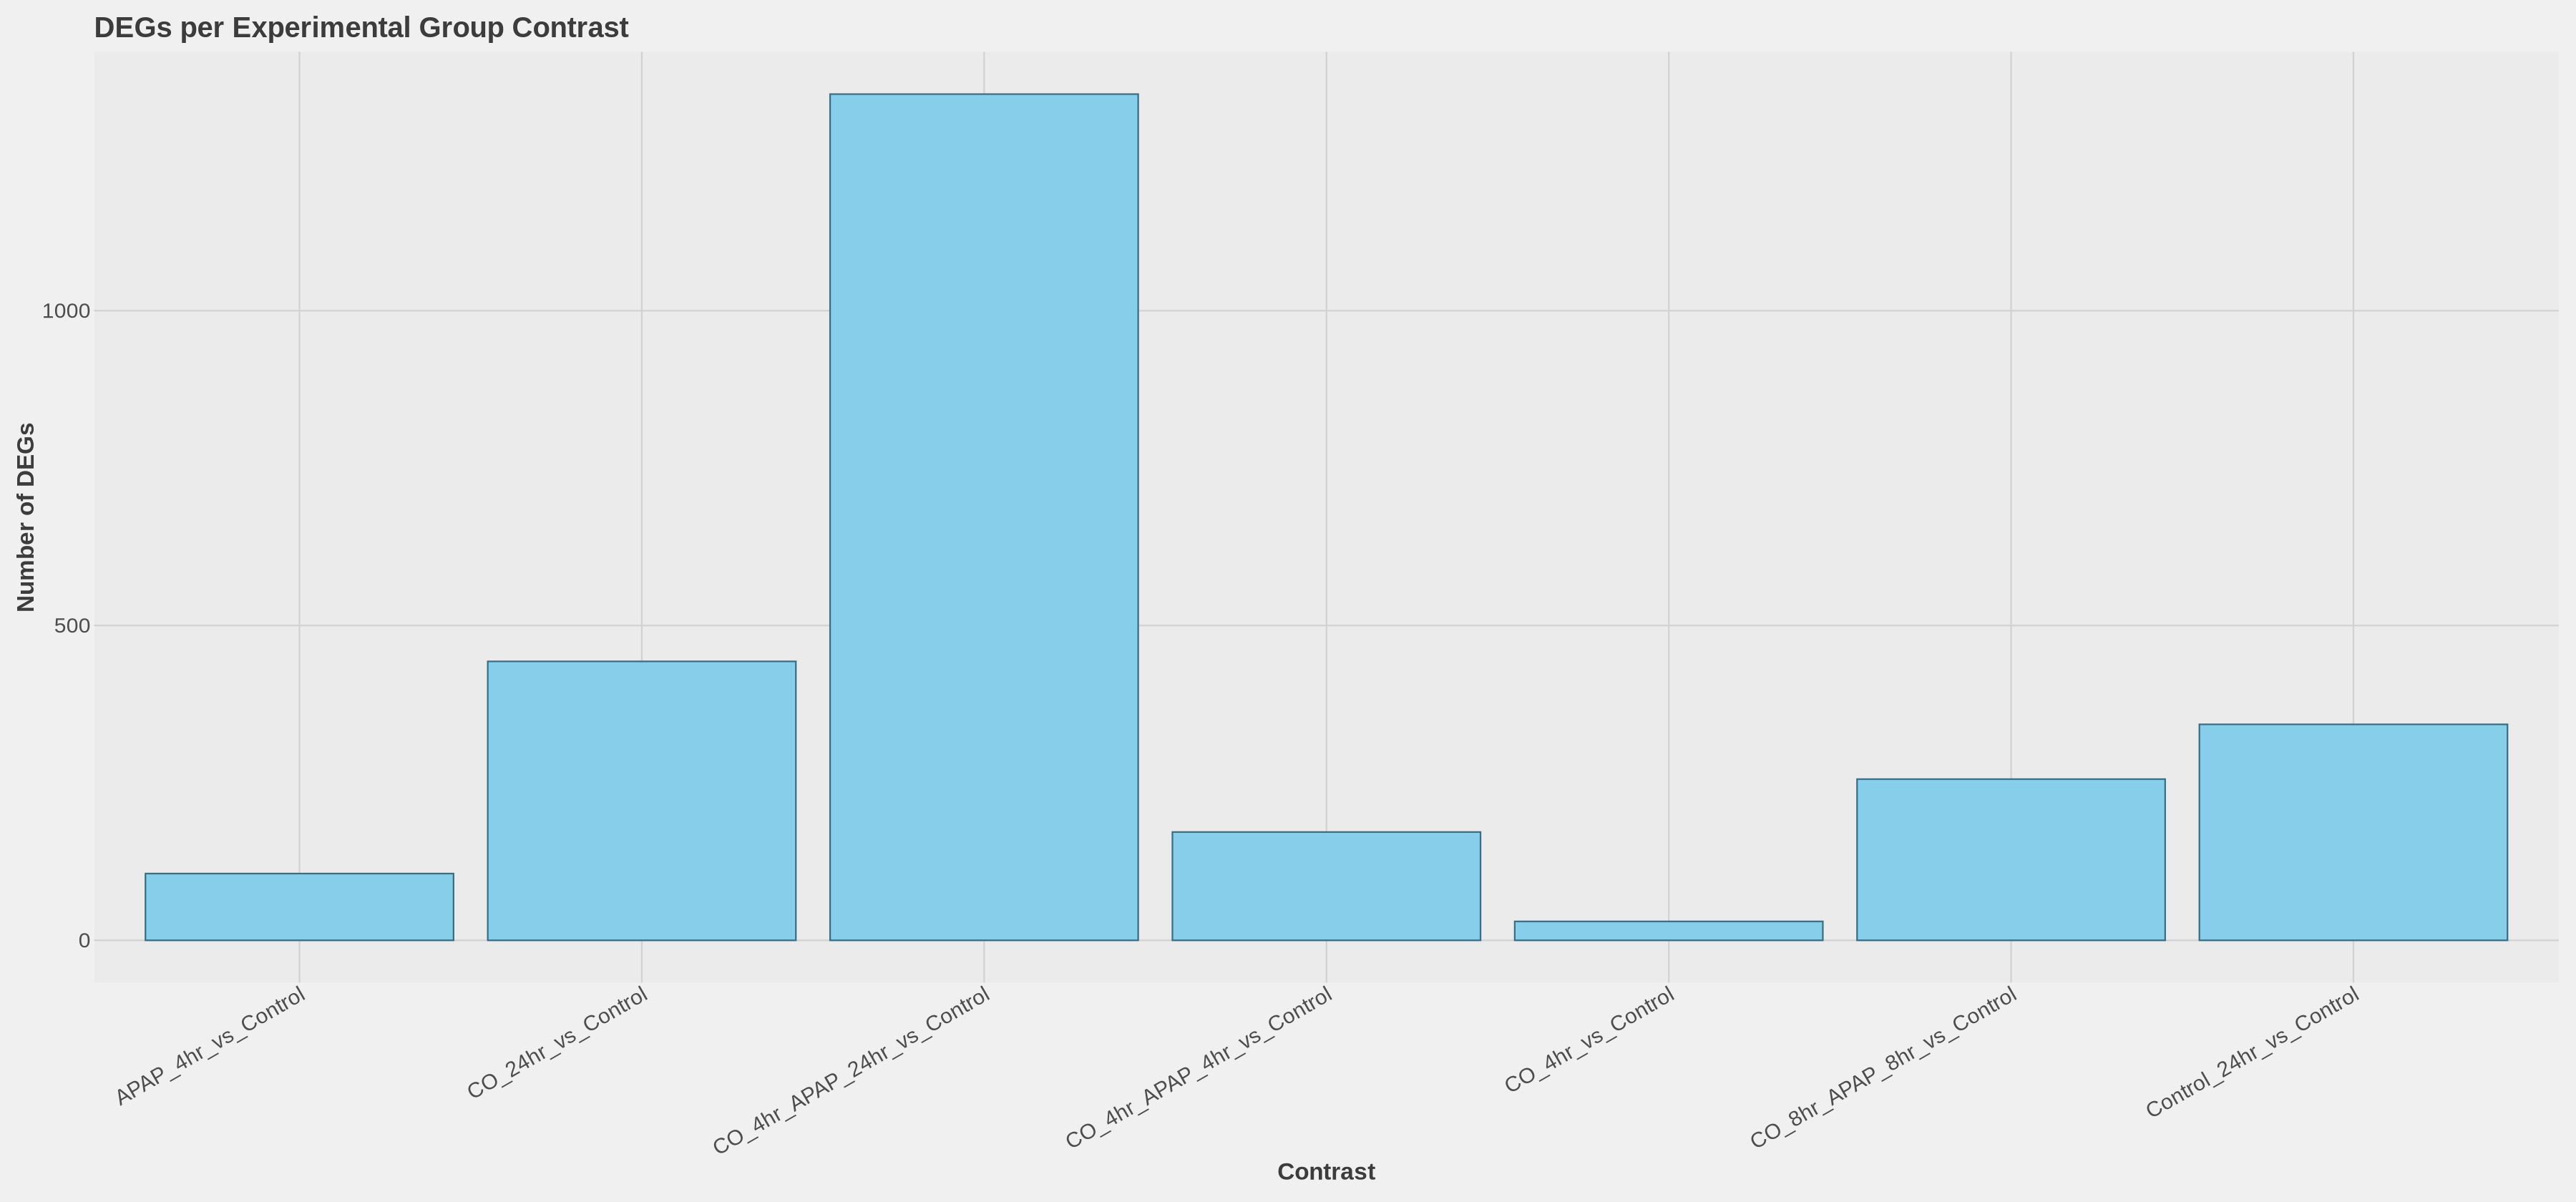

In [178]:
expCounts <- colSums(exp_sig_mat)
exp_df <- data.frame(
  contrast = names(expCounts),
  count = as.numeric(expCounts)
)
print(kable(exp_df, format = "pandoc"))

ggplot(exp_df, aes(x = contrast, y = count)) +
  geom_col(fill = "skyblue", color = "#397086") +
  labs(
    title = "DEGs per Experimental Group Contrast",
    x = "Contrast",
    y = "Number of DEGs"
  ) +
  theme_fivethirtyeight(base_size = 14) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1),
    plot.title = element_text(size = 24, face = "bold"),
    axis.title = element_text(size = 20, face = "bold"),
    axis.text = element_text(size = 18)
  )

**(1.b)** The following table and bar graph provide the number of DEGs found for each contrast in the "Treatment Interaction Test"




contrast                   count
------------------------  ------
co_time_4hr_vs_0hr            41
apap_time_4hr_vs_0hr         132
co_time4hr.apap_time4hr       18


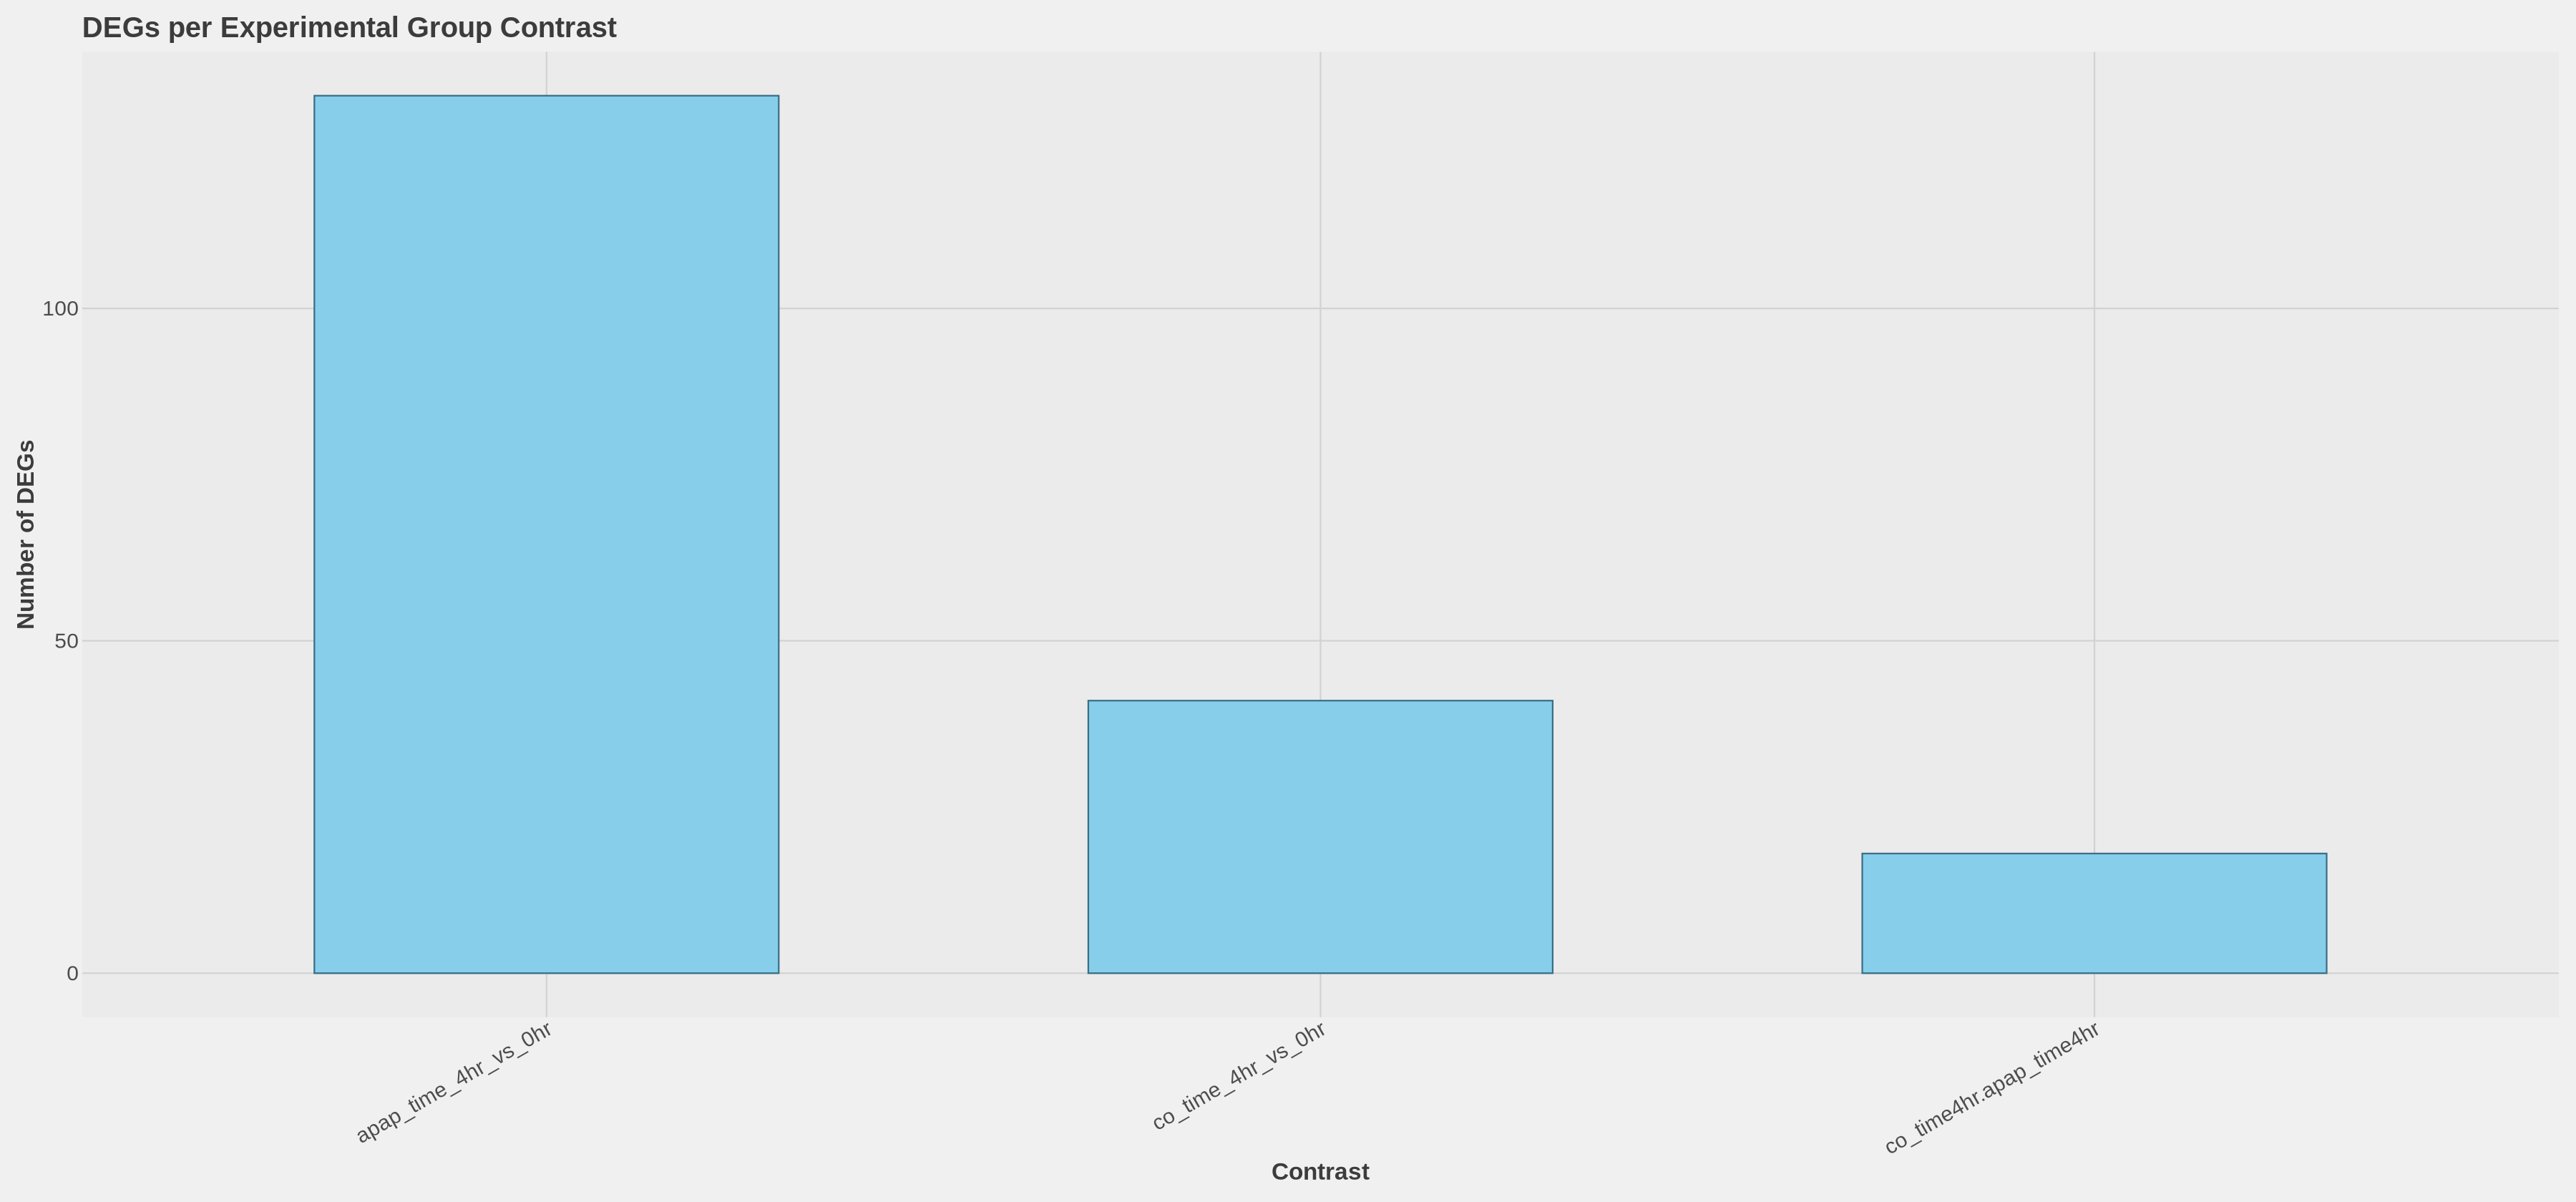

In [180]:
intCounts <- colSums(int_sig_mat)
int_df <- data.frame(
  contrast = names(intCounts),
  count = as.numeric(intCounts)
)
print(kable(int_df, format = "pandoc"))


ggplot(int_df, aes(x = contrast, y = count)) +
  geom_col(fill = "skyblue", color = "#397086", width = .6) +
  labs(
    title = "DEGs per Experimental Group Contrast",
    x = "Contrast",
    y = "Number of DEGs"
  ) +
  theme_fivethirtyeight(base_size = 14) +
  theme(axis.text.x = element_text(angle = 30, hjust = 1),
        plot.title = element_text(size = 24, face = "bold"),
        axis.title = element_text(size = 20, face = 'bold'),
        axis.text = element_text(size = 18))

**(2.a)** The following visualizes the Experimental Group Test matrix as a clustered heat map of member genes and contrasts as "Figure 1". (Analysis follows the visual)

Warning message:
“You defined `cell_fun` for a heatmap with more than 100 rows or
columns, which might be very slow to draw. Consider to use the
vectorized version `layer_fun`.”


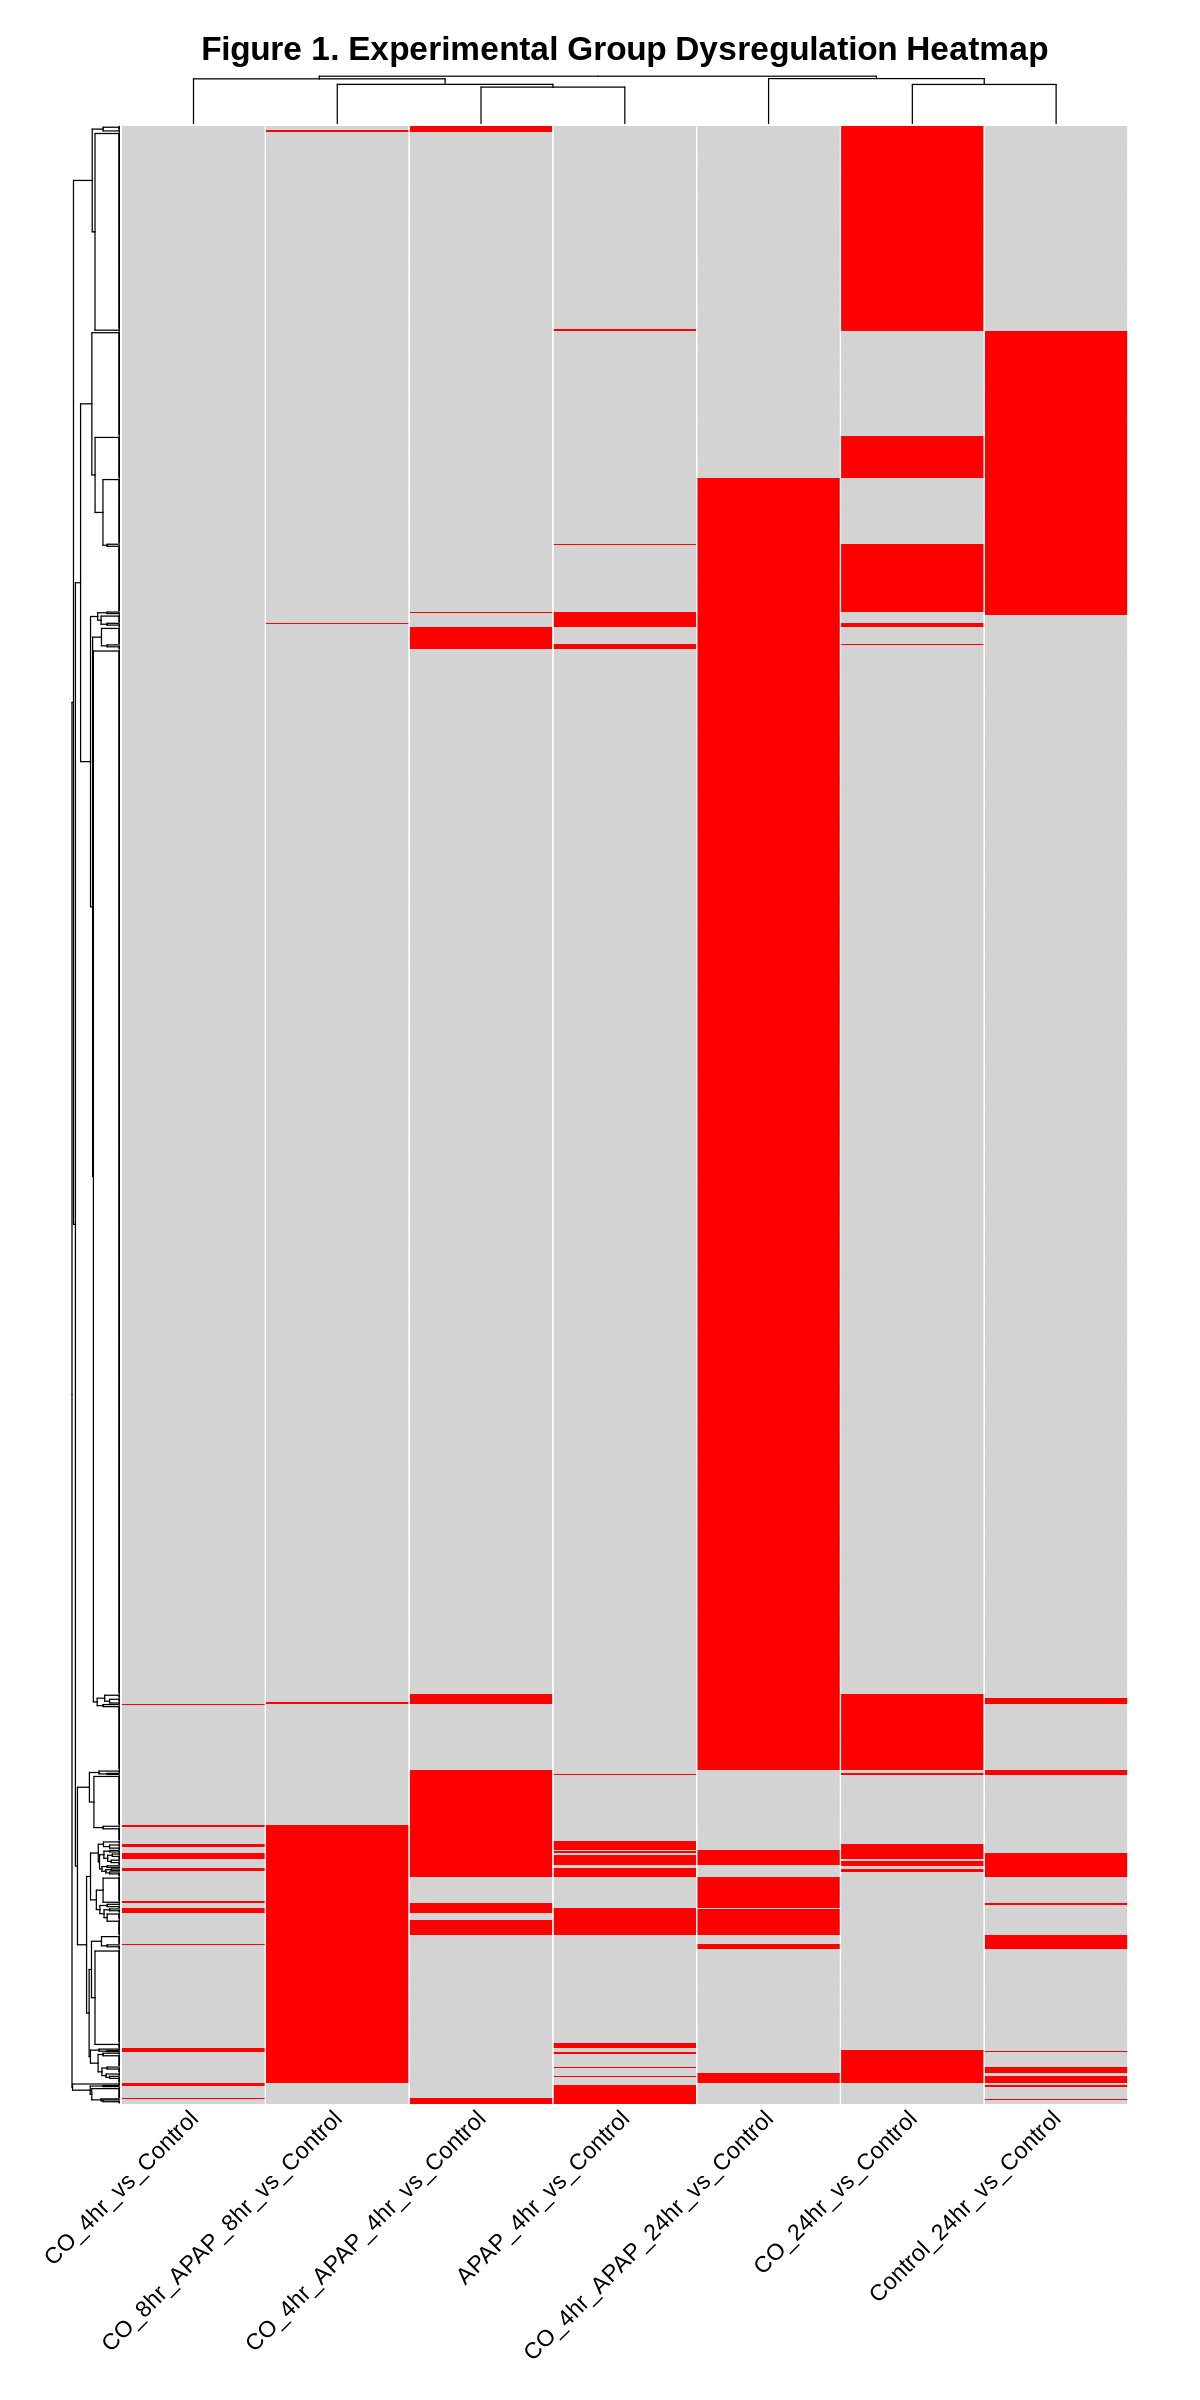

In [10]:
options(repr.plot.width=10, repr.plot.height=20)

row_dist <- proxy::dist(as.matrix(exp_sig_mat), method = "Jaccard")
col_dist <- proxy::dist(t(as.matrix(exp_sig_mat)), method = "Jaccard")

# Perform hierarchical clustering with average linkage
row_hclust <- hclust(row_dist, method = "average")
col_hclust <- hclust(col_dist, method = "average")

# Determine cell width and height dynamically
n_rows <- nrow(exp_sig_mat)
n_cols <- ncol(exp_sig_mat)

ht <- Heatmap(
  as.matrix(exp_sig_mat) * 1,
  # heatmap_legend_param = list(title = NULL, legend = FALSE),
  name = "Significant",
  col = c("0" = "lightgray", "1" = "red"),
  cluster_rows = row_hclust,
  cluster_columns = col_hclust,
  show_row_names = FALSE,
  show_column_names = TRUE,
  column_names_rot = 45,                # angled column names
  column_title = "Figure 1. Experimental Group Dysregulation Heatmap",
  column_title_gp = gpar(fontsize = 20, fontface = "bold"),
  column_title_side = "top",
  show_heatmap_legend = FALSE,   
  column_names_gp = gpar(fontsize = 14),
  row_names_gp = gpar(fontsize = 8),
  rect_gp = gpar(col = NA),             # no default cell borders
  # padding = unit(c(2, 2, 2, 2), "cm"), # top, right, bottom, left
  heatmap_legend_param = list(title = NULL, legend = FALSE),  # remove legend
  cell_fun = function(j, i, x, y, width, height, fill) {
    # Draw vertical white line between columns
    x_right <- convertX(x + width/2, "npc", valueOnly = TRUE)
    y_bottom <- convertY(y - height/2, "npc", valueOnly = TRUE)
    y_top <- convertY(y + height/2, "npc", valueOnly = TRUE)

    grid.lines(
      x = unit(c(x_right, x_right), "npc"),
      y = unit(c(y_bottom, y_top), "npc"),
      gp = gpar(col = "white", lwd = 1)
    )
  }
)

draw(ht, padding = unit(c(2, 4, 2, 4), "lines"))

Figure 1. is a hierarchically clustered heatmap of the full set DEGs that were found in at least of the individual contrasts between each treatment group and the zero hour control in the experimental group test. The clustering algorithm groups genes by similarity in the binary distribution of significant expression across all of the samples. Because the data is binary, the default euclidean distance proximity measure was not used. Since most of the genes are not expressed across most treatment group contrasts, Jaccard was chosen over Hamming as a proximity measure to ensure that genes would not be clustered together as a result of higher frequency of non-significant expression across contrasts. As a result, the gene clustering is based on agreement between which contrasts genes are significantly expressed rather than based on agreement on where they do not. This holds for the clustering of contrasts where they are grouped based on where there is agreement on what genes are DEGs rather than what genes are not. The heatmap shows disparity in level of perturbation, where the 4 hour co-extract with 24 hour acetaminophen exposures yielded the greatest amount of significant gene expression perturbation while the 4 hour exposure to the extract with no acetaminophen showed the least perturbation.

There are two experimental groups that were exposed only to co-extract: for 4 hours and 24 hours respectively. The general disparity in the genes with significant perturbation in these two groups might indicate different states of cellular activity at these different levels of exposure. This interpretation of disparity is fortified by the clustering distances between these contrasts in the horizontal dendrogram at the top of the heatmap. This could suggest that the effects of the extract does not perpetuate specific cellular functions over the length of exposures being studied for co-extract. This will be assessed in downstream analysis.

More agreement can be seen between experimental groups that were exposed to both the extracts for the same amount of time: 4 hours and 8 hours, respectively. There is more similarity between these experimental groups than the groups exposed only to the co-extract, being clustered together at a lower level of the dendrogram and having more overlap in the gene groups that showed significant expression. There is about as much similarity between the 4 hour bi-treatment group and the 4 hour acetaminophen-only treatment group as there is between the 4 and 8 hour bi-treatment groups. Given the relative similarity between these three groups compared to the amount of similarity with the 4 hour extract-only group, might suggest that there is a reductive effect on the disregulation occurring due to acetaminophen when exposed to co-extract. On the other hand, it could mean that the independent contribution to overall perturbation due the extract is simply less than that due to the acetaminophen without having a reductive effect. It will be difficult to parse the implications of these observations in downstream analysis due to the need for opportunity to distinguish the independent effects of both treatments at the 8 hour level. 

These observations do not in any way rule out the interactive effect of the treatments on functional activity that might be occurring in response to the exposure. At this level of analysis it is not possible to clarify genes that are known to participate in the same pathways as being significantly expressed. It is possible that the gene level clustering has identified some true biological signal but is much more likely that it reveals more information about the relationships between samples, that it does about relationships between genes. Downstream analysis will be performed for more robust clustering analysis

**(2.b)** The following visualizes the Experimental Group Test matrix as a clustered heat map of member genes and contrasts as "Figure 1". (Analysis follows the visual)

Warning message:
“You defined `cell_fun` for a heatmap with more than 100 rows or
columns, which might be very slow to draw. Consider to use the
vectorized version `layer_fun`.”


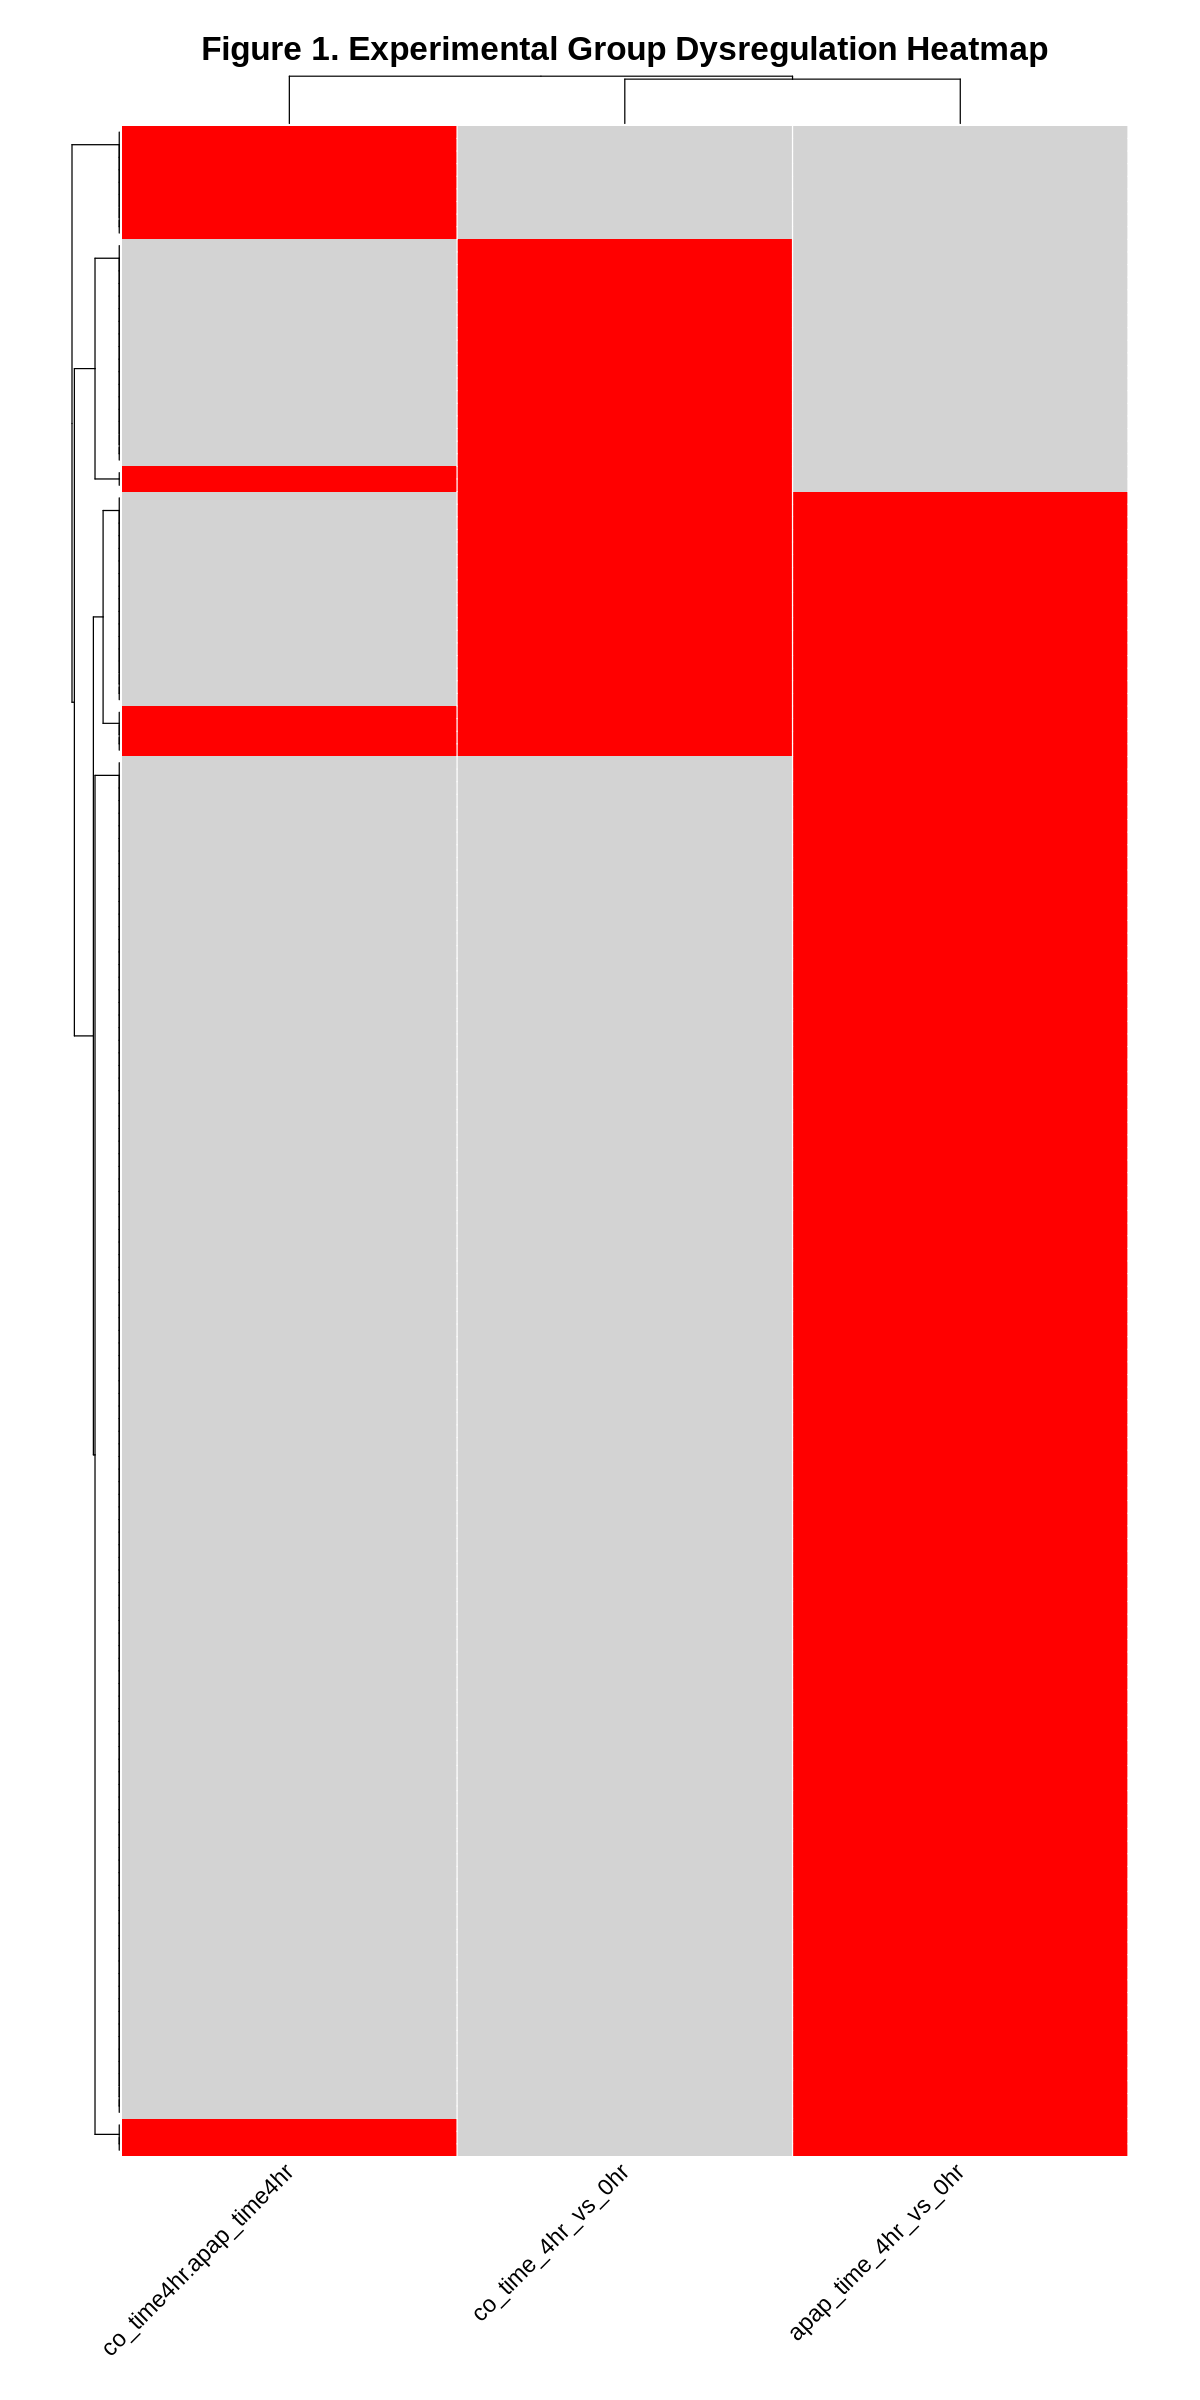

In [11]:
options(repr.plot.width=10, repr.plot.height=20)

row_dist <- proxy::dist(as.matrix(int_sig_mat), method = "Jaccard")
col_dist <- proxy::dist(t(as.matrix(int_sig_mat)), method = "Jaccard")

# Perform hierarchical clustering with average linkage
row_hclust <- hclust(row_dist, method = "average")
col_hclust <- hclust(col_dist, method = "average")

# Determine cell width and height dynamically
n_rows <- nrow(int_sig_mat)
n_cols <- ncol(int_sig_mat)

ht <- Heatmap(
  as.matrix(int_sig_mat) * 1,
  # heatmap_legend_param = list(title = NULL, legend = FALSE),
  name = "Significant",
  col = c("0" = "lightgray", "1" = "red"),
  cluster_rows = row_hclust,
  cluster_columns = col_hclust,
  show_row_names = FALSE,
  show_column_names = TRUE,
  column_names_rot = 45,                # angled column names
  column_title = "Figure 1. Experimental Group Dysregulation Heatmap",
  column_title_gp = gpar(fontsize = 20, fontface = "bold"),
  column_title_side = "top",
  show_heatmap_legend = FALSE,   
  column_names_gp = gpar(fontsize = 14),
  row_names_gp = gpar(fontsize = 8),
  rect_gp = gpar(col = NA),             # no default cell borders
  # padding = unit(c(2, 2, 2, 2), "cm"), # top, right, bottom, left
  heatmap_legend_param = list(title = NULL, legend = FALSE),  # remove legend
  cell_fun = function(j, i, x, y, width, height, fill) {
    # Draw vertical white line between columns
    x_right <- convertX(x + width/2, "npc", valueOnly = TRUE)
    y_bottom <- convertY(y - height/2, "npc", valueOnly = TRUE)
    y_top <- convertY(y + height/2, "npc", valueOnly = TRUE)

    grid.lines(
      x = unit(c(x_right, x_right), "npc"),
      y = unit(c(y_bottom, y_top), "npc"),
      gp = gpar(col = "white", lwd = 1)
    )
  }
)

draw(ht, padding = unit(c(2, 4, 2, 4), "lines"))

Figure 2. is a hierarchically clustered heatmap of the full set of DEGs that were found in any of the individual contrasts from the interaction test. The test was performed on a subset of samples restricted to exposures intervals of 0-4 hours for both treatments. This test was conducted as a robust means to identify DEGs that are expressed at levels statistically significant beyond was can be explained by the treatments independently. However, the circumstances under which the test was conducted leave doubt in the accuracy of its results. Due to the full rank requirement for the predictive matrix made for generating a test statistic, the number of samples were less than ideal for this test which could lead to type II errors (failing to reject the null). It is possible that there are more genes whose expression in the presence of both treatments was different to a statistically significant level than what occurs as a result of each treatment independently. In addition, the fact that the maximum exposure was limited to 4 hours for each treatment can further confound the results since it is evident when looking at all of the contrasts to the 0 hour control across the treatment groups that maximum perturbation does not occur at 4 hour exposure mark. Relaxing the statistical threshold for rejecting the null is not sufficient because it implicitly assumes that the distribution the test is conducted in would be the same if there were additional samples for higher exposure times. As a consequence the analysis of interactivity will not consider the results of this test. 


**(3)** ...

In [16]:
head(exp_sig_mat)

,CO_4hr_APAP_24hr_vs_Control,CO_24hr_vs_Control,Control_24hr_vs_Control,CO_4hr_APAP_4hr_vs_Control,CO_8hr_APAP_8hr_vs_Control,CO_4hr_vs_Control,APAP_4hr_vs_Control
ENSG00000075624.17,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,FALSE
ENSG00000125148.7,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE
ENSG00000184009.13,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,FALSE
ENSG00000177410.14,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE,TRUE
ENSG00000135480.17,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE,FALSE
ENSG00000099860.10,TRUE,FALSE,FALSE,TRUE,TRUE,TRUE,TRUE


add UpSetPlot stuff here

Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font width unknown for character 0x09 in encoding latin1”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font width unknown for character 0x09 in encoding latin1”


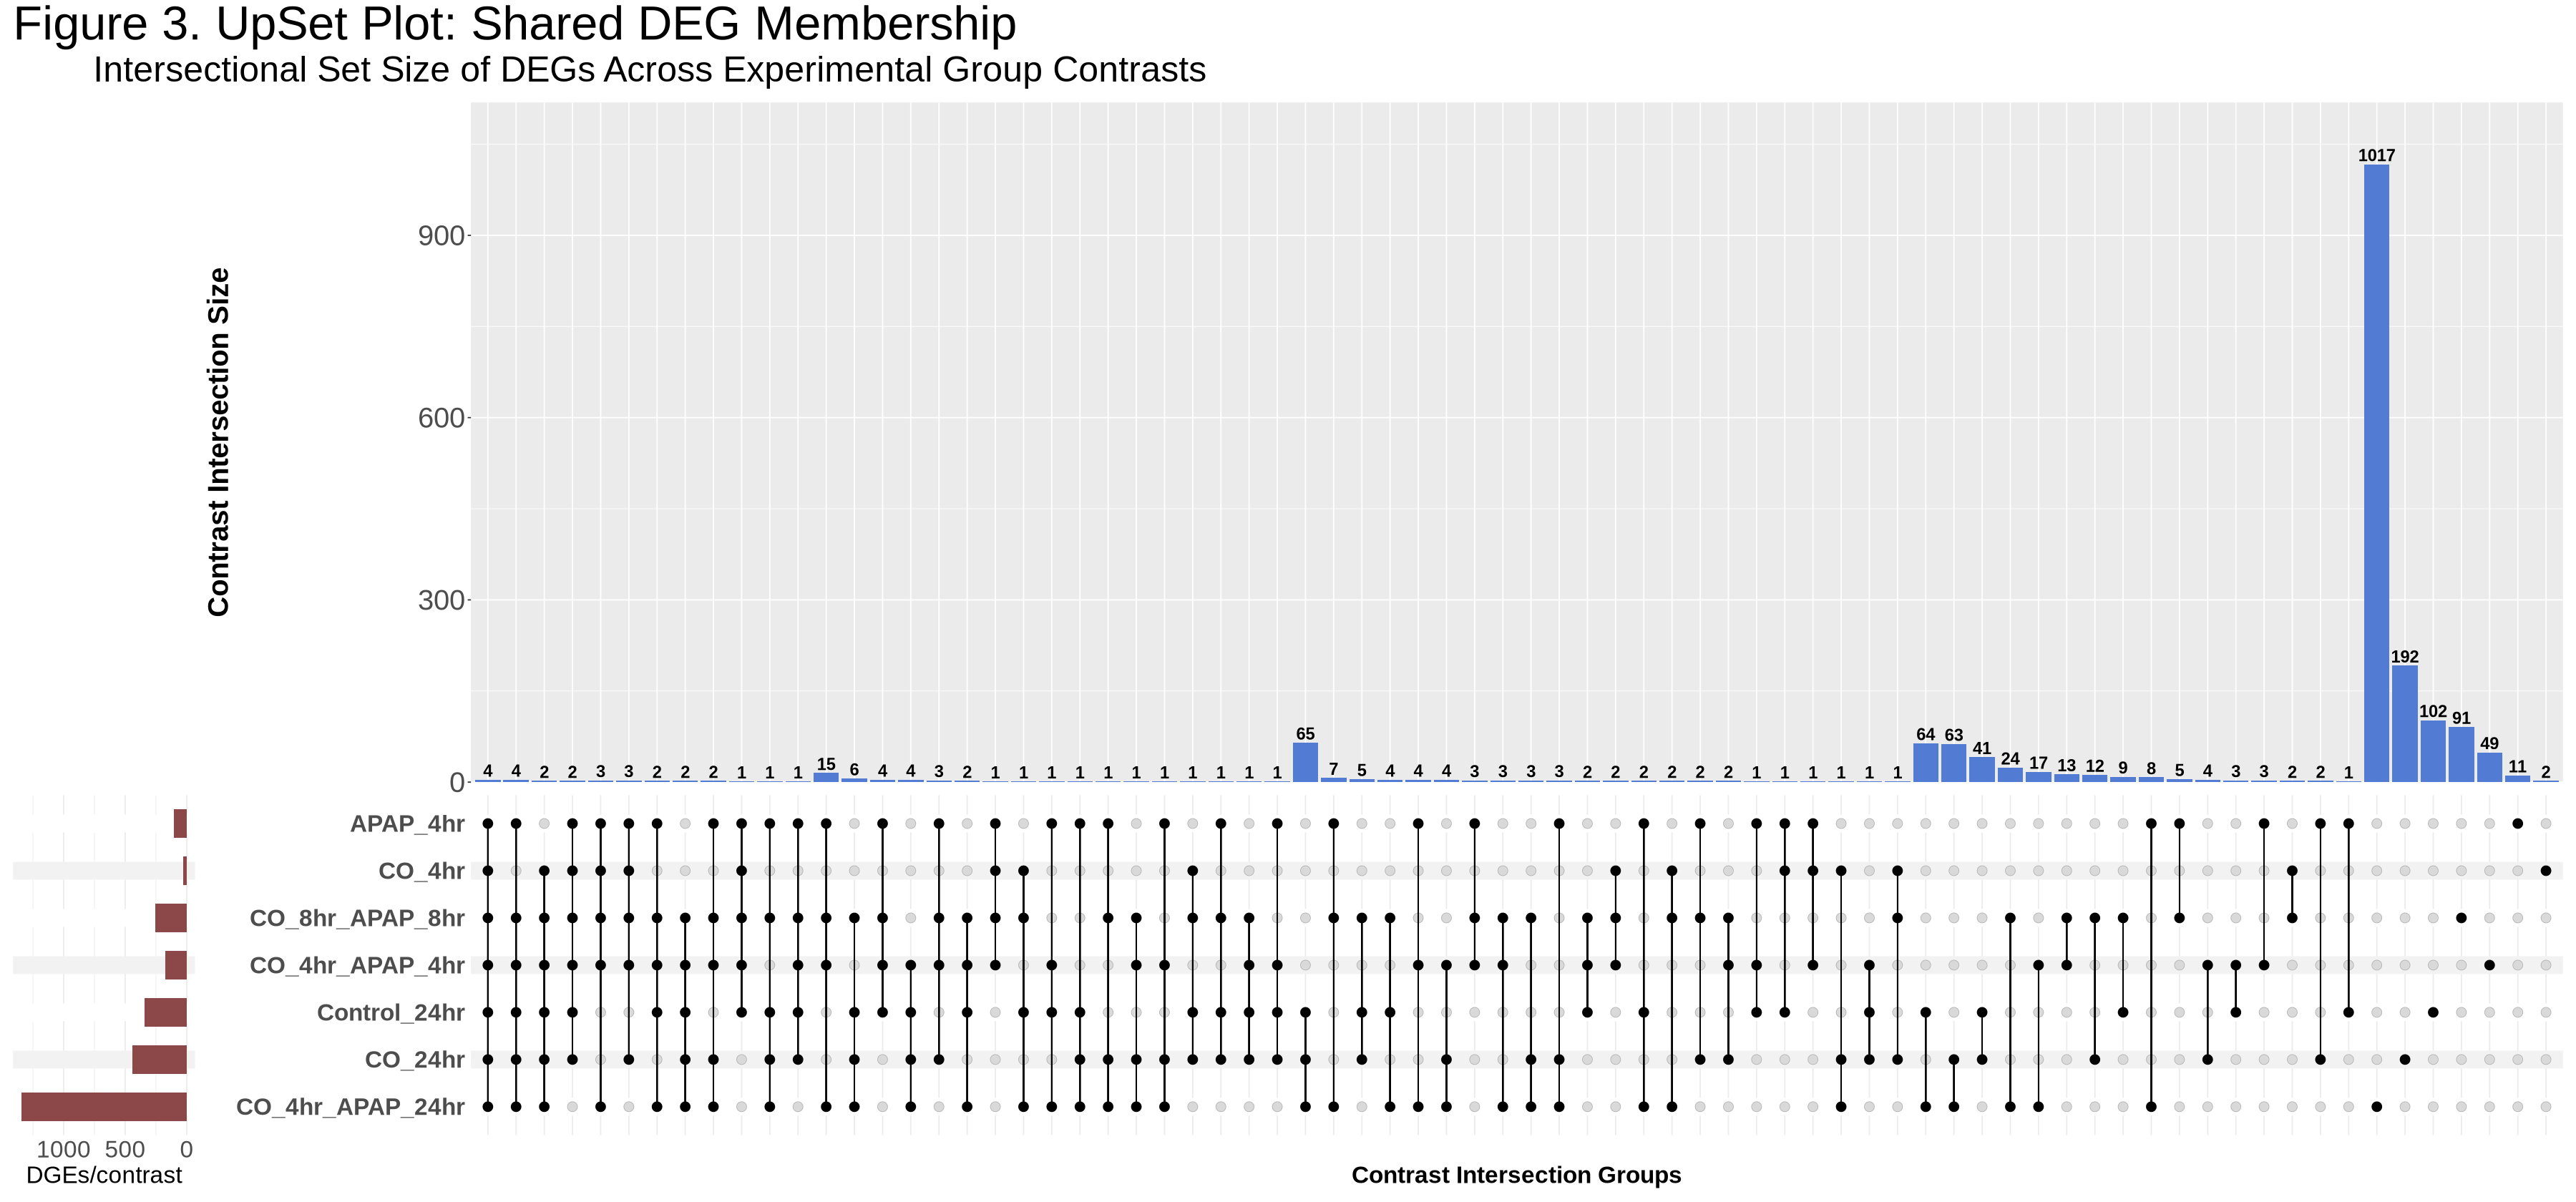

In [177]:
options(repr.plot.width=30, repr.plot.height=14)

upSet_df <- as.data.frame(exp_sig_mat)
colnames(upSet_df) <- sub("_vs_.*", "",
          colnames(upSet_df), 
          ignore.case = TRUE)

p = upset(
  upSet_df,
  intersect = colnames(upSet_df),
  name = "Contrast Intersection Groups", # names matrix
  base_annotations = list(
    # names vertical bars
    'Contrast Intersection Size' = intersection_size(
      counts = TRUE,
      bar_number_threshold = 1, # ensures that counts at top of bar
      mapping = aes(fill = 'intersection'),
      text = list(
        color = 'black', # Forces the text to be black instead of white
        size = 5,
        fontface = "bold"         # Optional: adjust the font size of the numbers
      )
    ) + 
    # 0.3 (30%) expansion gives the 1013 bar enough "sky" to breathe
    scale_y_continuous(expand = expansion(mult = c(0, 0.1)))
  ),

  set_sizes = upset_set_size(
    mapping = aes(fill = 'set')) +
    ylab("DGEs/contrast"), # names horizonal bars

  min_size = 1,
  sort_sets = FALSE,
  sort_intersections_by = c('degree','cardinality'), # orders by intersection degree and then frequency in intersection
  width_ratio = 0.08,
  
  themes = upset_modify_themes(
    list(
      # Targets the side bar chart (Set sizes)
      'overall_sizes' = theme(axis.text.x = element_text(size = 20),
                              axis.title.x = element_text(size = 20)),
      
      # Targets the top bar chart (Intersection sizes)
      'Contrast Intersection Size' = theme(axis.text.y = element_text(size = 24),
                                  axis.title.y = element_text(size = 24, face = "bold"),
                                  axis.text.x = element_blank(),
                                  axis.ticks.x = element_blank(),
                                  axis.title.x = element_blank() 
                                  ),
      
      # Targets the dot matrix labels (Set names)
      'intersections_matrix' = theme(axis.text.y = element_text(size = 20, face = "bold"),
                                  axis.text.x = element_blank(),
                                  axis.title.x = element_text(size = 20,face = "bold")
                                )
    )
  )
  
) & scale_fill_manual( # Use '&' instead of '+' to apply to all sub-plots
  values = c(
    'intersection' = "#527cd4",
    'set' = "#8c4848"
  ),
  breaks = c('intersection', 'set') # Explicitly define breaks to avoid level mismatch
) & 
theme(legend.position = "none")

p + plot_annotation(title = "Figure 3. UpSet Plot: Shared DEG Membership",
      subtitle = "\tIntersectional Set Size of DEGs Across Experimental Group Contrasts",
      # caption = "put caption here",
      theme = theme(plot.title = element_text(size = 40), 
        plot.subtitle = element_text(size = 30))
      )

Figure 3. is an "UpSet" plot that reveals the same information you would expect from venn diagrams but as a cleaner visual interface for the significant number of intersections that exist between the experimental group contrasts. 

The blue bars show the number of DEGs that exist in a given intersection and the points in the matrix underneath indicate the contrasts contributing to the intersection set. In other words, if there is a point in the column associated with the vertical bar above it the contrast for the row with that point contributes to the intersection. The order of the Contrast Intersection Groups is by the number of the contrasts that contribute to the intersection. The first vertical bar are the number of DGEs found in the intersection of all contrasts (degree 7), the next set of bars are the DEG set-sizes for the intersections that exist between any six of the contrasts (degree 6), followed by the next set of bars that apply to contrast intersections of degree 5, and so on. (You can see in the vertical plot where there is a jump in the bar heights, which identifies the start of a new degree of intersection for contributing contrasts). The last set of bars on the far right represent the size of the set of DEGs that belong to a given contrast and no other contrasts. 

The red bars give you a reference point for appreciating the magnitudes of the intersections that include a given contrast by providing a relative sense of the number of DGEs found in each contrast overall. There is a strong correlation between the number of DEGs identified for a contrast and the number of intersections that each contrast contributes to.

Most identified DGEs are identified exclusively for a single contrast. The largest set of the contrast-exclusive sets was that identified for the CO_4hr_APAP_24_hr contrast containing 1017 DGEs unique to it, followed by the CO_24hr contrast with 192 unique DGEs and then the Control_24hr contrast with 102 unique DEGs. The smallest set of the contrast-exclusive sets was that identified for the co_4hr group containing 2 DGEs unique to it. There were 4 DGEs identified in all contrasts, 15 DGEs found in all contrasts that included acetaminophen and 0 DGEs found in all contrasts including the extract (1 DGE was found across all of the contrasts excluding the extract if you exclude the 4 hour exposure treatment group). There were 63 DGEs that were shared between the 24 hour exposure to the extract alone and the 4 hour extract exposure with 24 acetaminophen exposure. The table below includes the number of instances each contrast is included in an intersection between contrasts that had at least one shared DGE.

In [175]:
upset_info <- upset_data(upSet_df, colnames(upSet_df))
unique_intersections <- unique(upset_info$with_sizes[, colnames(upSet_df)])
participation_counts <- as.data.frame(colSums(unique_intersections))
colnames(participation_counts) <- c("Intersection Inclusion Count")
participation_counts["Contrast"] <- rownames(participation_counts)
rownames(participation_counts) <- NULL
participation_counts <- participation_counts[,c(2,1)]
print(kable(participation_counts, format = "pandoc"))



Contrast            Intersection Inclusion Count
-----------------  -----------------------------
CO_4hr_APAP_24hr                              35
CO_24hr                                       36
Control_24hr                                  34
CO_4hr_APAP_4hr                               38
CO_8hr_APAP_8hr                               43
CO_4hr                                        17
APAP_4hr                                      35


In [184]:
print(head(upSet_df))
print(dim(upSet_df))

                   CO_4hr_APAP_24hr CO_24hr Control_24hr CO_4hr_APAP_4hr
ENSG00000075624.17             TRUE    TRUE         TRUE            TRUE
ENSG00000125148.7              TRUE    TRUE         TRUE           FALSE
ENSG00000184009.13             TRUE    TRUE         TRUE            TRUE
ENSG00000177410.14             TRUE    TRUE        FALSE           FALSE
ENSG00000135480.17             TRUE    TRUE         TRUE           FALSE
ENSG00000099860.10             TRUE   FALSE        FALSE            TRUE
                   CO_8hr_APAP_8hr CO_4hr APAP_4hr
ENSG00000075624.17            TRUE   TRUE    FALSE
ENSG00000125148.7            FALSE  FALSE    FALSE
ENSG00000184009.13            TRUE   TRUE    FALSE
ENSG00000177410.14           FALSE  FALSE     TRUE
ENSG00000135480.17           FALSE  FALSE    FALSE
ENSG00000099860.10            TRUE   TRUE     TRUE
[1] 1926    7


In [185]:
# 1. Get the upset data
upset_info <- upset_data(upSet_df, colnames(upSet_df))

# 2. Extract the intersection labels and pair them with your original rownames
intersection_mapping <- data.frame(
  GeneID = rownames(upSet_df),
  Group = upset_info$presence$intersection
)

# 3. Create a clean nested list of Gene IDs per group
gene_list <- split(intersection_mapping$GeneID, intersection_mapping$Group)

ERROR: Error in data.frame(GeneID = rownames(upSet_df), Group = upset_info$presence$intersection): arguments imply differing number of rows: 1926, 2694


Start here: this df has columns 8:17 that include intersection info but nees to understand what the difference is between each of these attributes

In [188]:
print(colnames(upset_info$with_sizes))

 [1] "CO_4hr_APAP_24hr"            "CO_24hr"                    
 [3] "Control_24hr"                "CO_4hr_APAP_4hr"            
 [5] "CO_8hr_APAP_8hr"             "CO_4hr"                     
 [7] "APAP_4hr"                    "intersection"               
 [9] "exclusive_intersection"      "in_exclusive_intersection"  
[11] "in_inclusive_union"          "in_inclusive_intersection"  
[13] "in_exclusive_union"          "exclusive_intersection_size"
[15] "inclusive_intersection_size" "exclusive_union_size"       
[17] "inclusive_union_size"       


In [191]:
write.csv(upset_info$with_sizes, "../de_analysis/shared_dges.csv")

___
___

This analyzes patterns in direction of expression across experimental group contrasts. This provides insight in to how the DEGs varied across the contrasts and what this may impl about relationships between treatment groups